# [LAB-02] 비지도 학습ㅣ04-페르소나 분석(실습코드).ipynb

# 페르소나 분석이란

## 군집 번호는 아무에게도 설명할 수 없다 — 문장으로 바꿔야 한다

| ❌ 이렇게 보고하면 | ✅ 이렇게 보고해야 |
|---|---|
| "1번 그룹에 마케팅을 집중하겠습니다" | "소득은 높은데 지출은 적은 40대 그룹에 집중하겠습니다" |
| → 듣는 사람은 1번 그룹이 누구인지 알 수 없다 | → 누구를 왜 노리는지가 문장에 담긴다 |

- 군집분석이 내놓는 결과는 0, 1, 2 같은 숫자 이름표일 뿐이다 — 그 자체로는 어떤 고객인지 아무것도 말해 주지 않는다
- 각 군집이 어떤 사람들인지 한 문장으로 설명할 수 있도록 **대표값을 뽑아내는 작업**이 페르소나 분석이다
- 대표값이 문장으로 바뀌는 순간, 그 문장이 곧 **마케팅 액션**으로 이어진다
- **군집분석을 실무에 활용하는 독립 기법**이다

## #01. 준비작업 
### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import * 

from pandas import DataFrame, crosstab
import joblib

# 정규성 검정 
from scipy.stats import normaltest

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기 

In [2]:
origin = load_data("mall_customers")
origin.head()

📚 이 데이터 세트는 쇼핑몰 고객의 인구통계학적 특성과 소비 습관에 대한 정보를 담고 있습니다. 고객 ID, 성별, 나이, 연간 소득, 지출 점수와 같은 다양한 속성이 포함되어 있습니다. (출처: https://www.kaggle.com/datasets/shwetabh123/mall-customers)


,고객ID,성별,나이,연수입,지출점수
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 3. 데이터 전처리 - 변수 타입 정리 

In [3]:
origin = my_qtcheck.set_type(origin, as_category=["성별"])

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   고객ID    200 non-null    int64   
 1   성별      200 non-null    category
 2   나이      200 non-null    int64   
 3   연수입     200 non-null    int64   
 4   지출점수    200 non-null    int64   
dtypes: category(1), int64(4)
memory usage: 6.6 KB



# 데이터 소개와 변수 선택

## 쇼핑몰 고객 200명 — 소득과 소비 성향은 따로 논다

### A. 데이터 소개

| 컬럼 | 의미 | 범위 |
|---|---|---|
| 고객ID | 고객 번호 | 분석에 사용하지 않음 |
| 성별 | Female / Male | 여성 56% / 남성 44% |
| 나이 | 나이 | 18~70세 (평균 38.8) |
| 연수입 | 연간 소득 (단위: 천 달러) | 15~137 (평균 60.6) |
| 지출점수 | 쇼핑몰이 매긴 소비 성향 점수 | 1~99 (평균 50.2) |

> 데이터셋에 포함되어 있는 **지출점수**는 실제 결제 금액이 아니라 쇼핑몰이 자체 기준으로 매긴 소비 성향 점수(1~100)다. 그래서 소득과 소비 성향이 서로 독립적으로 움직인다.

### B. 군집화 변수 선택

| 변수 | 사용 여부 | 설명 |
|---|---|---|
| 고객ID | ❌ | 단순 일련번호, 거리 계산에 의미가 없다 |
| 성별 | ❌ | 문자열이라 거리를 잴 수 없다 (해석에는 쓴다) |
| 나이 | ❌ | 소득·소비와 다른 방향으로 흩어져 그룹의 경계를 흐린다 (해석에는 쓴다) |
| 연수입 | ⭕ | 고객을 나누는 핵심 축 |
| 지출점수 | ⭕ | 고객을 나누는 핵심 축 |

---

# 군집을 만드는 변수 vs 설명하는 변수

## 마케팅 목표 → 이번 분석의 목적은 연수입과 지출점수에 따른 고객 분류이다.

| 구분 | 쓰는 곳 | 이번 데이터의 경우 |
|---|---|---|
| 군집화 변수 | 거리를 계산해 그룹을 나눌 때 | 연수입, 지출점수 |
| 해석 변수 | 나뉜 그룹이 어떤 사람들인지 설명할 때 | 연수입, 지출점수 + 나이, 성별 |

**군집화 변수 — 적을수록 좋다**
관련 없는 변수를 넣으면 덩어리가 뭉개진다. 변수를 줄이면 그룹의 경계가 뚜렷해진다.

**해석 변수 — 많아도 좋다**
해석은 가진 정보를 모두 동원해도 된다. 나누는 데 안 쓴 변수도 설명에는 쓸 수 있다.

> 실무에서 **"왜 나이는 빼고 묶었나요?"**라는 질문을 받을 수 있다 — 이때 답할 문장이 아래에 있다

> "나이로 나눈 게 아니라, 나눠 놓고 보니 나이가 달랐습니다."

- 이쪽이 훨씬 강한 근거다 — 실제로 그런 뒤에서 나이 분포로 확인한다

## #01. 준비작업 
### 4. 군집화에 사용할 변수 선택 

In [4]:
df = origin[["연수입", "지출점수"]]
df.head()

,연수입,지출점수
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### 5. 데이터 스케일링 


In [5]:
# save_path를 지정하면 학습된 스케일러가 파일로 저장된다 
# -- > 신규 고객을 '똑같은 기준'으로 변환할 때 다시 불러 쓴다 
sdf = my_prep.scaling(df, method="standard", 
                      save_path="model/mall_scaler.pkl")

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
연수입               15.00 ~ 137.00            -1.74~2.92
지출점수                1.00 ~ 99.00            -1.91~1.89

스케일러 저장: model/mall_scaler.pkl (StandardScaler)


## #02. 군집 모형 적합 
### 1. 군집수 확정 (1/2)

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
연수입               15.00 ~ 137.00            -1.74~2.92
지출점수                1.00 ~ 99.00            -1.91~1.89


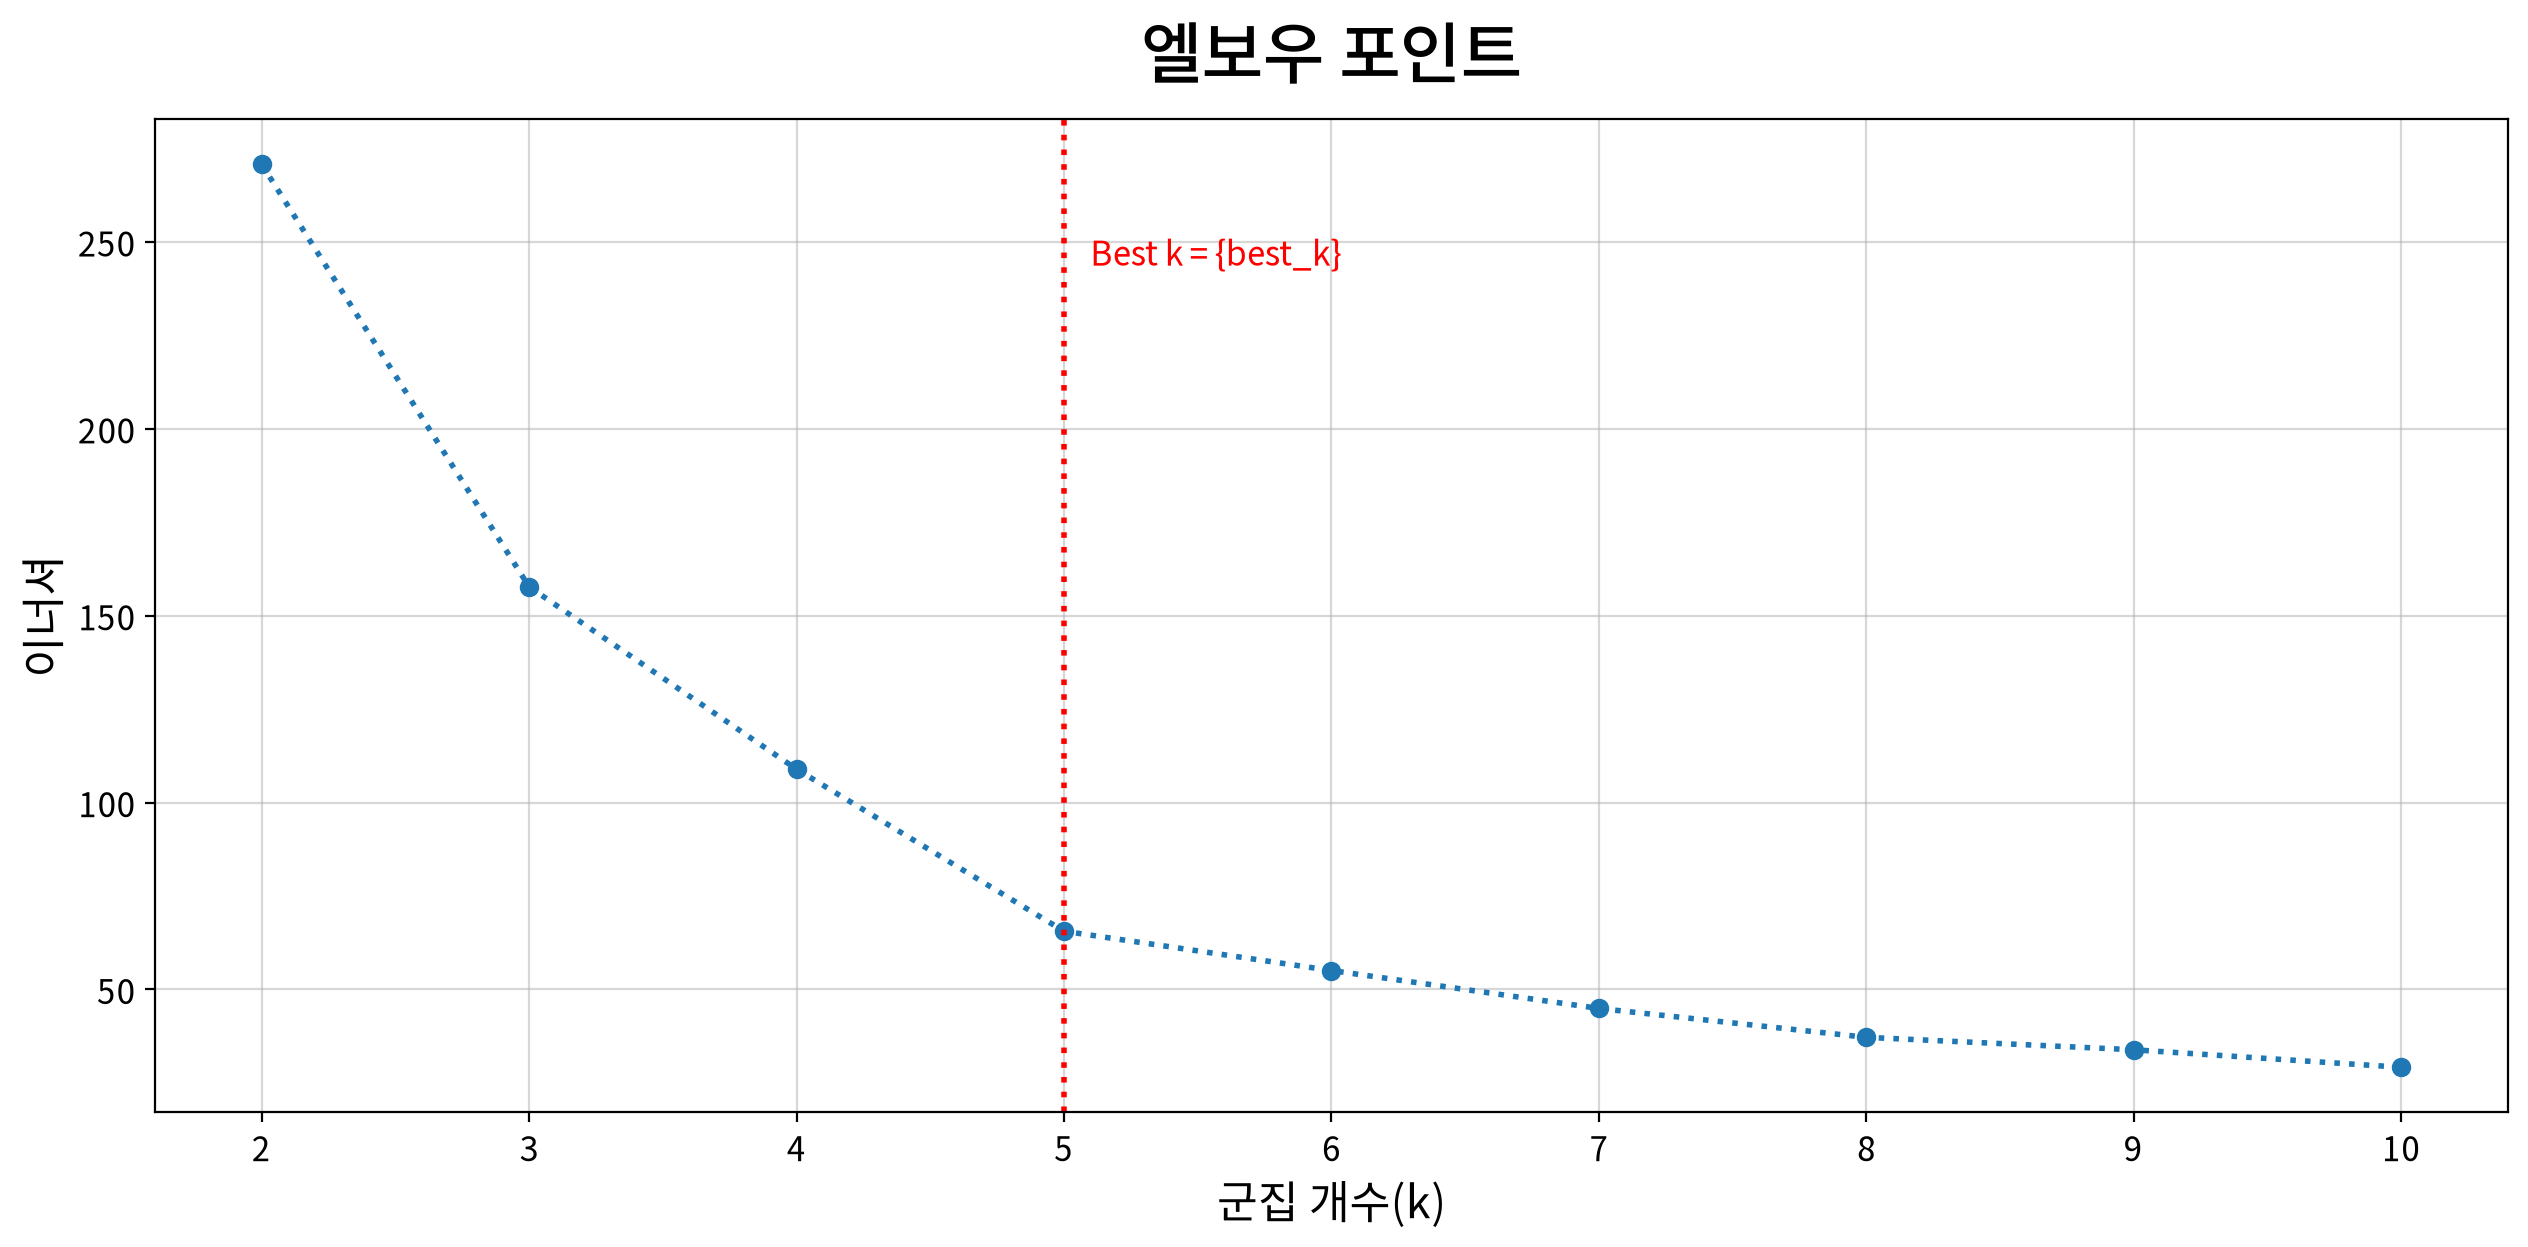

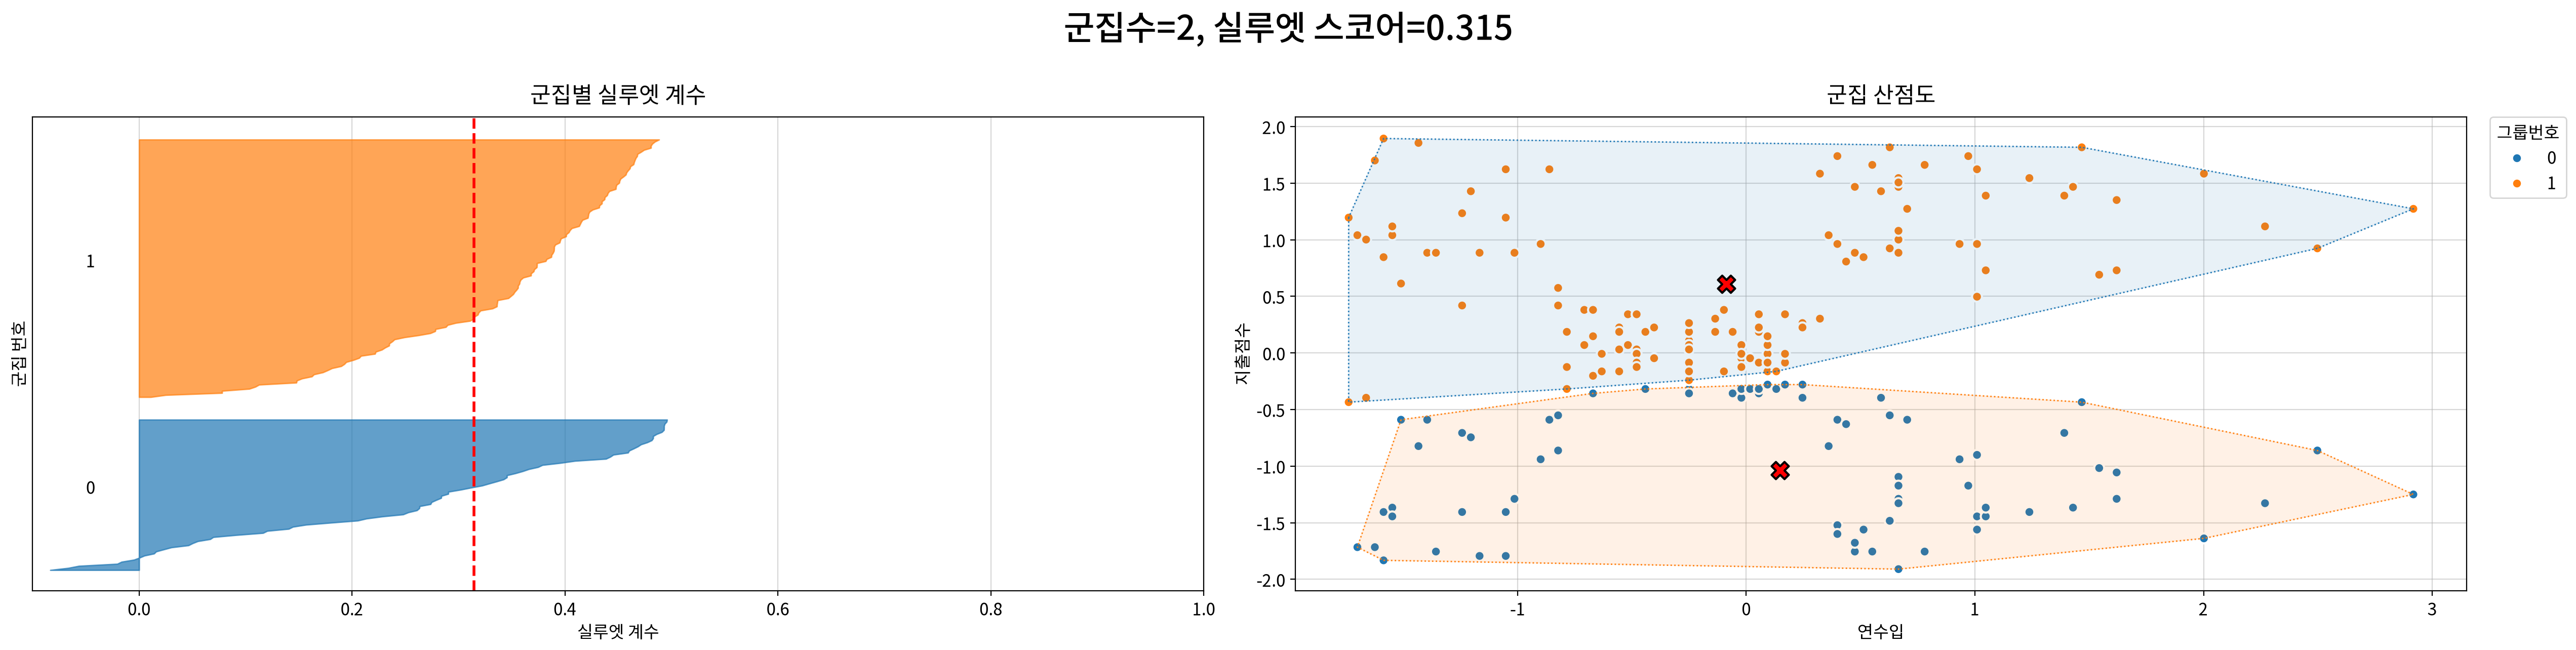

[1단계] 엘보우 포인트: k = 5 (뭉침만 확인 -> 후보)
[2단계] 실루엣 균형지수: k = 2 (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다
 . k = 5 : 균형지수 0.0797(스코어 0.5547, 두께비 3.6818)
 . k = 2 : 균형지수 0.1162(스코어 0.3147, 두께비 1.7027)
------------------------------------------------------------
 >>> 최종선택 : k = 2
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한번 더 확인할 것)


,k,이너셔,감소량,스코어,전체면적,두께비,최소상대면적,균형지수
0,2,270.704,NaN,0.315,62.940,1.703,0.628,0.116
1,3,157.704,113.000,0.467,93.317,3.237,0.685,0.099
2,4,108.921,48.783,0.494,98.781,4.348,0.516,0.059
3,5,65.568,43.353,0.555,110.931,3.682,0.529,0.080
4,6,55.057,10.511,0.540,107.976,8.100,0.182,0.012
5,7,44.911,10.146,0.526,105.269,7.900,0.227,0.015
6,8,37.182,7.729,0.456,91.240,4.300,0.287,0.030
7,9,33.854,3.328,0.455,91.058,6.125,0.301,0.022
8,10,29.167,4.687,0.448,89.634,6.571,0.262,0.018


In [6]:
final_k, result_df = my_cluster.best_k(df, verbose=True)
result_df

# #02. 군집 모형 적합

### 1. 군집수 확정 - 군집수 판단 근거

- 이 함수가 쓰는 **균형지수**는 실루엣 스코어를 **두께비율**(가장 큰 군집 ÷ 가장 작은 군집)로 분배하는데, 군집 크기가 원래 데이터 불균형이 없는 고른 데이터(예: 붓꽃 품종별 50송이)를 전제로 만든 지표이기 때문이다.
- 고객 데이터는 **중간층이 두껍고 극단 집단이 얇은 것이 정상**이다.
- 이건 데이터의 결함이 아니라 시장의 실제 모습이다.
- 그래서 이 데이터에서는 **두께비율의 페널티가 과도**해지기 때문에 실루엣 넓이 비율에 대한 채택값을 신뢰하기 어렵다.

> 지표는 데이터의 성격에 맞는 것을 채택해야 한다.
> 어떤 지표도 모든 데이터에 일괄적으로 적용되지는 않는다. (도메인 지식의 중요성)
---

## 2. 최적 k 결정

### 구매·사용량 기준에 따른 고객 층 분류
*출처: ZDF Werbefernsehen GmbH(2025)*

| 고객층 | 구매·사용 기준 특성 |
|---|---|
| 신규 구매 고객 | 최초 구매 단계로 이용 이력이 짧고 재구매 여부가 미확정 |
| 간헐적 구매 고객 | 구매 주기가 불규칙하고 구매 빈도가 낮음 |
| 반복 구매 고객 | 일정 기간 내 재구매가 꾸준히 이어짐 |
| 정기·고빈도 구매 고객 | 정기적으로 자주 구매하며 충성도·유지율이 높음 |
| 대량 구매 고객 | 1회 구매 금액과 수량이 크고 매출 기여도가 높음 |

- 이는 엘보우 포인트가 제시한 k값과도 일치하므로 최적의 k값을 5로 결정함

### 3. 모형 적합 

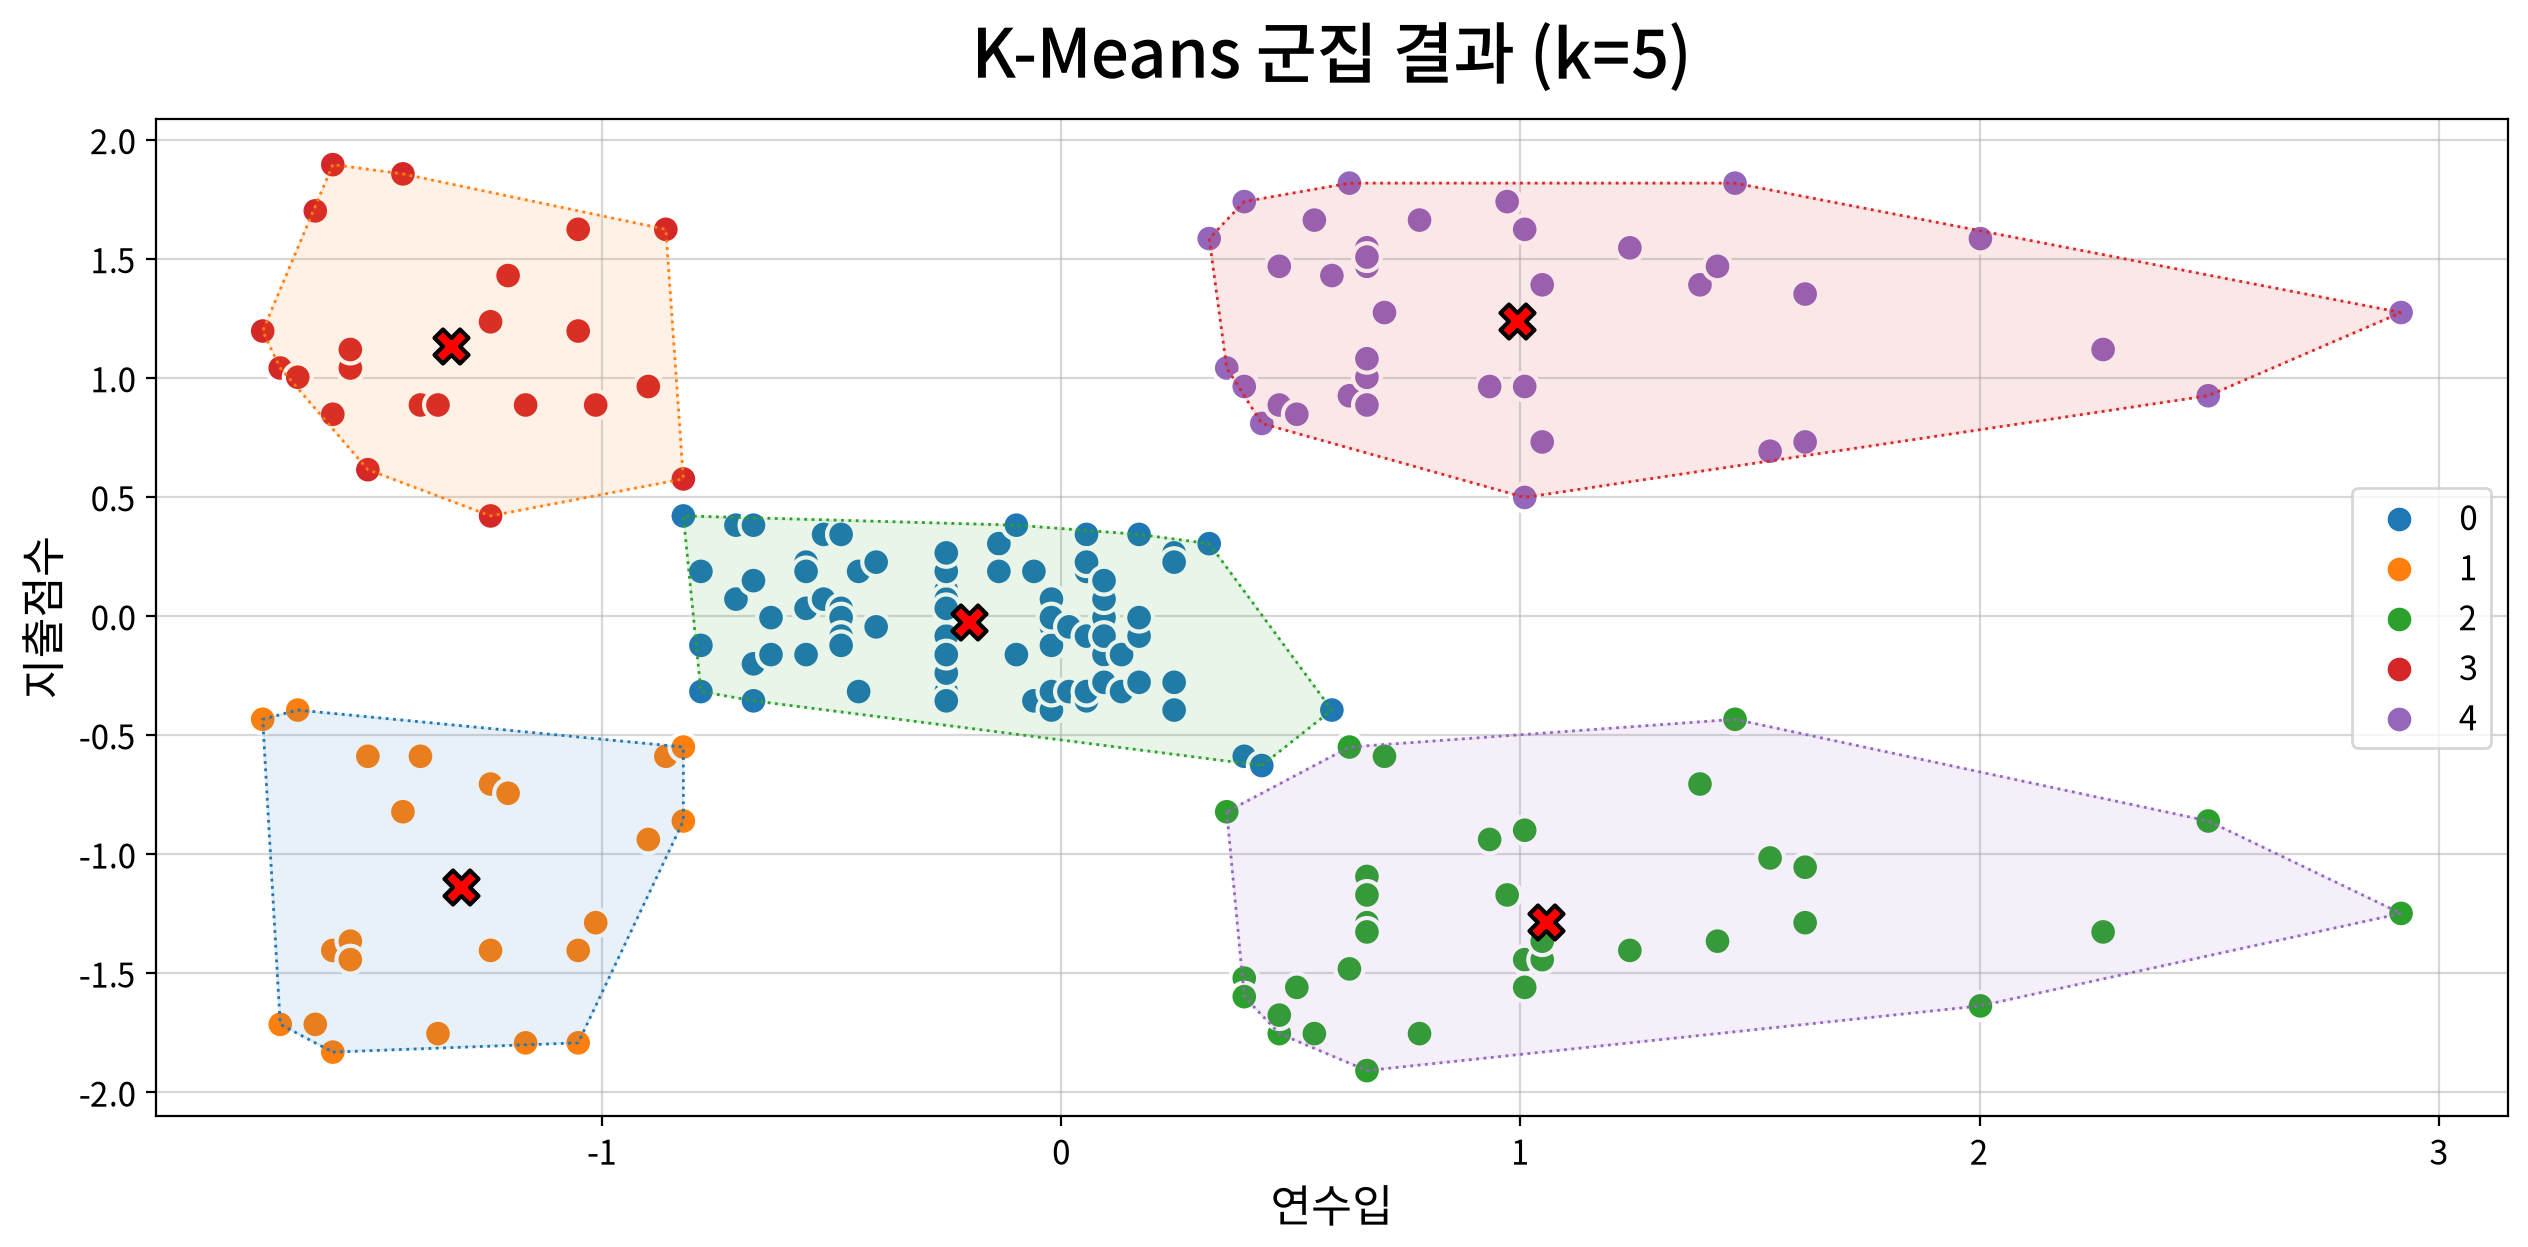

In [7]:
best_k =5

# my_cluster.kmeans()가 학습 -> 군집 번호 부여 -> 중심점 정리까지 한 번에 처리한다 
estimator, cdf, center_df = my_cluster.kmeans(df, k=best_k,
                                              cluster_name="ClusterID", verbose=False)

### 4. 군집 형태 확인 
앞서 확인한 그래프의 축은 원본 값을 쓴다 \
스케일링된 값(-1.2, 0.8,...)으로 그래프를 그리면 \
연수입 80처럼 실제 수치를 읽을 수 없기 때문에 원본 데이터를 통해 확인한다 

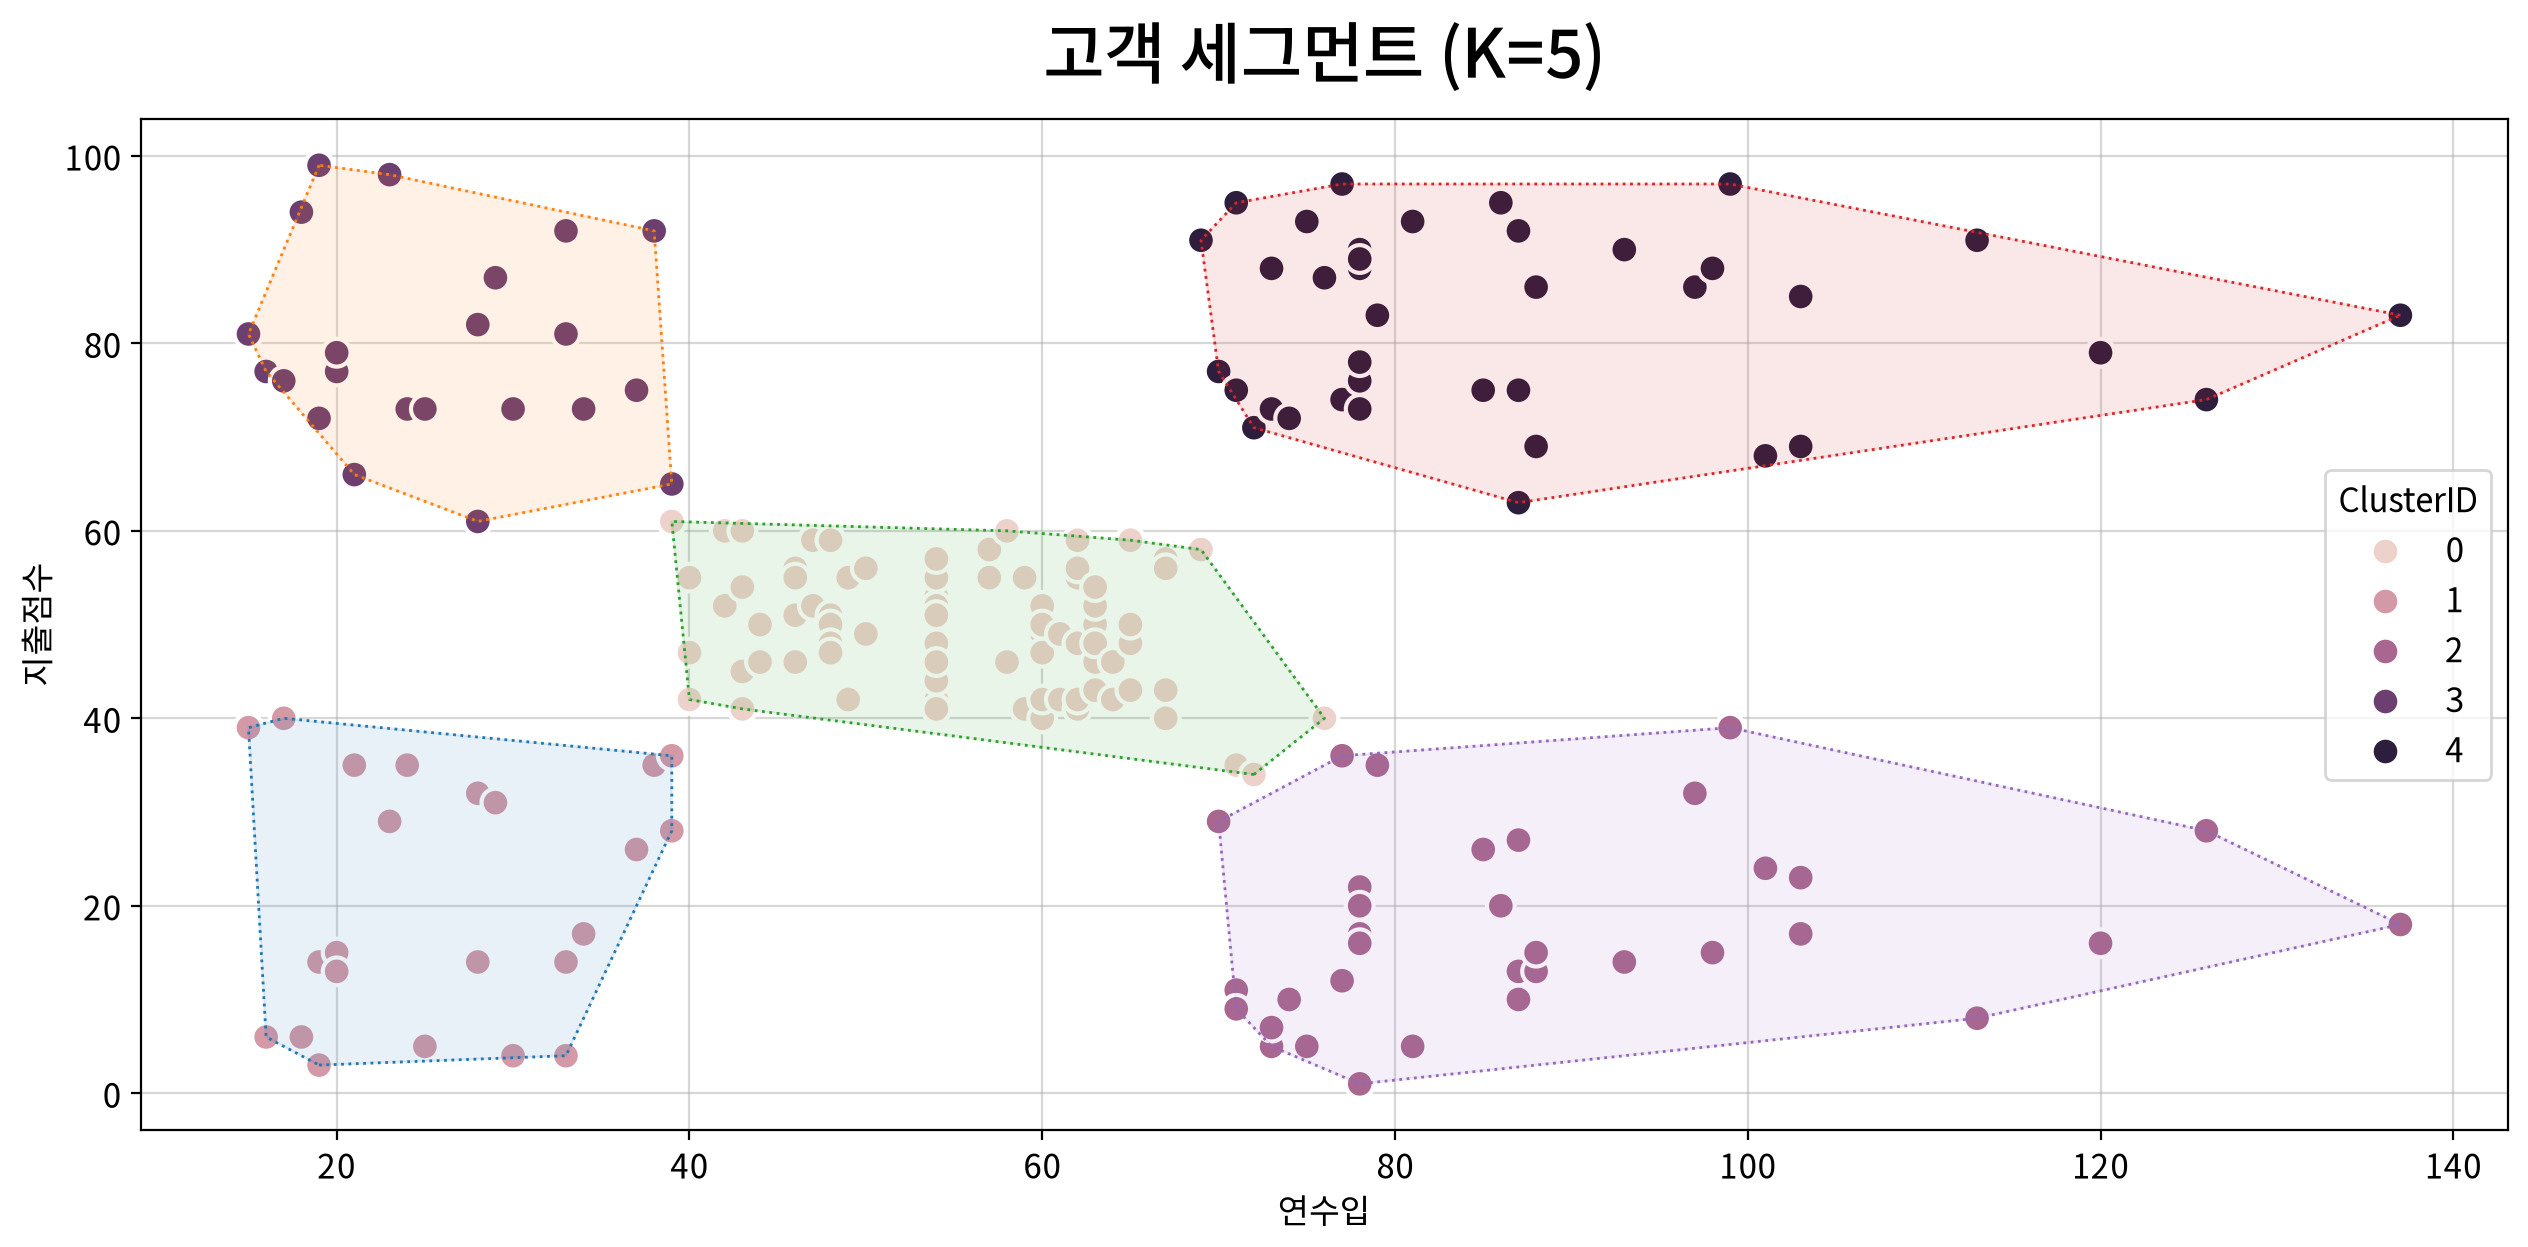

In [8]:
vdf = df.copy() # 원본 데이터 복사 
vdf["ClusterID"] = estimator.labels_ # 복사한 원본에 군집 번호 컬럼 추가 

my_plot.scatterplot(data=vdf, x="연수입", y="지출점수", hue="ClusterID", 
                    title=f"고객 세그먼트 (K={best_k})")

# #02. 군집 모형 적합 (원래 단위)

## 4. 군집 형태 확인 (결과 확인)

**고객 세그먼트 (K=5)**

산점도: x축 연수입(0~140), y축 지출점수(0~100). 색상별 5개 군집이 각각 좌상단(빨강), 중앙(파랑), 좌하단(주황), 우상단(보라), 우하단(초록)에 부채꼴/타원 형태로 분포.

**네 모서리 + 가운데**
주사위의 5눈 같은 배치다.
- **연수입**과 **지출점수**가 서로 독립적으로 움직이기 때문
- 소득이 높다고 많이 쓰는 것도, 낮다고 적게 쓰는 것도 아니다

### 읽는 방법 — 두 축의 조합으로 읽는다

| 지출점수 \ 연수입 | 낮음 | 높음 |
|---|---|---|
| 높음 | 소득은 적은데 많이 쓴다 | 소득도 많고 많이 쓴다 |
| 낮음 | 소득도 적고 적게 쓴다 | 소득은 많은데 적게 쓴다 |

---

# 군집 유형별 대표값 도출 → 페르소나

## 변수의 성격에 따라 대표값이 달라진다

### A. 대표값 선택 기준

| 변수 유형 | 대표값 | 이유 |
|---|---|---|
| 연속형 (나이, 금액 등) | **평균** — 종 모양 분포일 때 | 흔한 값을 잘 대표한다 |
| 연속형 | **중앙값** — 한쪽으로 치우쳤을 때 | 극단값에 흔들리지 않는다 |
| 범주형 (성별, 등급 등) | **최빈값** (가장 많이 나온 값) | 평균을 낼 수 없다 |

> 종 모양인지 아닌지는 **정규성 검정**으로 판단한다

### B. 어떤 변수를 고를까

| 선정 기준 | 설명 |
|---|---|
| 분리력이 큰가 | 군집마다 값이 확실히 다른가 |
| 말로 설명되는가 | "이 그룹은 OO이 높다"고 말할 수 있는가 |
| 실무에 쓸 수 있는가 | 전략·기획으로 이어지는가 |

> 보통 3~6개 변수면 충분하다

### 1. 원본 데이터에 군집 번호 붙이기 
학습은 스케일링 된 데이터로, 해석은 원본 데이터로 한다 \
스케일링된 값은 사람이 읽을 수 없기 때문 

In [9]:
pdf = origin.copy()
pdf["ClusterID"] = estimator.labels_
pdf.head()

,고객ID,성별,나이,연수입,지출점수,ClusterID
0,1,Male,19,15,39,1
1,2,Male,21,15,81,3
2,3,Female,20,16,6,1
3,4,Female,23,16,77,3
4,5,Female,31,17,40,1


### 2. 군집에 사용된 변수와 그 밖의 변수 구분 

In [10]:
# 군집을 만든 변수 (거리 계산에 사용)
cluster_columns = list(df.columns)

# 군집을 설명할 변수 (군집화에 쓰지 않은 나이, 성별도 포함한다)
num_columns = ["나이"] + cluster_columns
cat_columns = my_qtcheck.get_categorical_column_names(origin)

print("군집화 변수: ", cluster_columns)
print("해석 - 연속형: ", num_columns)
print("해석 - 범주형: ", cat_columns)

군집화 변수:  ['연수입', '지출점수']
해석 - 연속형:  ['나이', '연수입', '지출점수']
해석 - 범주형:  ['성별']


### 3. 군집별 대표값 집계 

In [11]:
persona_list = [] # 결과를 저장할 리스트 

# --- 1) 군집수 만큼 반복 --- 
for i in range(best_k): 
    # 1-1) 현재 군집에 속한 데이터만 추출
    cluster_data = pdf[pdf["ClusterID"] == i]

    # 1-2) 군집별 요약 통계 생성 
    persona_item = {"Cluster":i, "count":len(cluster_data)}

    # 1-3) 연속형 변수: 정규분포면 평균, 아니면 중앙값 
    for column in num_columns:
        stat, p = normaltest(cluster_data[column]) #정규성 검정 

        if p > 0.05: # 정규분포를 따르면 평균값 
            persona_item[column] = round(cluster_data[column].mean(), 3)
            print(f"군집{i} - {column}: 정규분포를 따름 (p={p:.3f}) -> 평균값 사용")    
        else: # 정규분포를 따르지 않으면 중앙값 
            persona_item[column] = round(cluster_data[column].median(), 3)
            print(f"군집{i} - {column} : 정규분포를 따르지 않음 (p={p:.3f}) -> 중앙값 사용")

    # 1-4) 범주형 변수: 최빈값 
    for column in cat_columns:
        persona_item[column] = cluster_data[column].value_counts().idxmax()
        print(f"군집{i} - {column} : 최빈값 = {persona_item[column]}")

    # 1-5) 결과 리스트에 추가 
    persona_list.append(persona_item)

# --- 2) 결과 확인 --- 
# 데이터 프레임으로 변환하고 군집 번호 기준으로 정렬 
persona_df = DataFrame(persona_list).sort_values(by='Cluster')  
persona_df 

군집0 - 나이 : 정규분포를 따르지 않음 (p=0.000) -> 중앙값 사용
군집0 - 연수입 : 정규분포를 따르지 않음 (p=0.013) -> 중앙값 사용
군집0 - 지출점수 : 정규분포를 따르지 않음 (p=0.047) -> 중앙값 사용
군집0 - 성별 : 최빈값 = Female
군집1 - 나이: 정규분포를 따름 (p=0.846) -> 평균값 사용
군집1 - 연수입: 정규분포를 따름 (p=0.084) -> 평균값 사용
군집1 - 지출점수 : 정규분포를 따르지 않음 (p=0.003) -> 중앙값 사용
군집1 - 성별 : 최빈값 = Female
군집2 - 나이: 정규분포를 따름 (p=0.602) -> 평균값 사용
군집2 - 연수입 : 정규분포를 따르지 않음 (p=0.002) -> 중앙값 사용
군집2 - 지출점수: 정규분포를 따름 (p=0.441) -> 평균값 사용
군집2 - 성별 : 최빈값 = Male
군집3 - 나이: 정규분포를 따름 (p=0.228) -> 평균값 사용
군집3 - 연수입: 정규분포를 따름 (p=0.160) -> 평균값 사용
군집3 - 지출점수: 정규분포를 따름 (p=0.638) -> 평균값 사용
군집3 - 성별 : 최빈값 = Female
군집4 - 나이: 정규분포를 따름 (p=0.132) -> 평균값 사용
군집4 - 연수입 : 정규분포를 따르지 않음 (p=0.001) -> 중앙값 사용
군집4 - 지출점수 : 정규분포를 따르지 않음 (p=0.016) -> 중앙값 사용
군집4 - 성별 : 최빈값 = Female


,Cluster,count,나이,연수입,지출점수,성별
0,0,81,46.000,54.000,50.000,Female
1,1,23,45.217,26.304,17.000,Female
2,2,35,41.114,85.000,17.114,Male
3,3,22,25.273,25.727,79.364,Female
4,4,39,32.692,79.000,83.000,Female


# #03. 페르소나 도출

## 3. 군집별 대표값 집계 (결과 확인)

> 각 군집에 대표값을 집계 → 그 대표값을 설명하는 이름을 붙인다.

### A. 페르소나 표 — 군집화는 두 변수로, 해석은 나이·성별까지

| Cluster | count | 나이 | 연수입 | 지출점수 | 성별 | 붙일 이름 |
|---|---|---|---|---|---|---|
| 0 | 81 | 46.000 | 54.000 | 50.000 | Female | 중간 다수 집단 |
| 1 | 23 | 45.217 | 26.304 | 17.000 | Female | 저관여 (저소득·저지출) |
| 2 | 35 | 41.114 | 85.000 | 17.114 | Male | 설득 대상 (고소득·저지출) |
| 3 | 22 | 25.273 | 25.727 | 79.364 | Female | 적극 소비층 (저소득·고지출) |
| 4 | 39 | 32.692 | 79.000 | 83.000 | Female | 핵심 고객 (고소득·고지출) |

- 나이와 성별은 군집화에 쓰지 않았는데도 표에 들어간다 → **해석 변수**이기 때문
- 군집마다 나이·성별 분포가 정규분포를 따르는지, 유의미하게 차이 나는지 하나씩 검정 → 대부분 정규분포 미달로 최빈값/평균값을 상황에 맞게 채택

```python
# 군집별 대표값 집계 (연속형: 평균/중앙값, 범주형: 최빈값)
persona = pdf.groupby("ClusterID").agg(
    count=("ClusterID", "size"),
    나이=("나이", "mean"),
    연수입=("연수입", "mean"),
    지출점수=("지출점수", "mean"),
    성별=("성별", lambda s: s.mode()[0])
).reset_index()

persona
```

---



# 이름 붙이기와 마케팅 액션

## 이름이 붙는 순간, 그 이름이 곧 실행할 일이 된다.

### A. 위치 → 이름 → 액션 순서로 이어진다

| 위치 | 이름 | 마케팅 액션 |
|---|---|---|
| 고소득·고지출 (군집 4) | 핵심 고객 | VIP 혜택, 신상품 우선 안내 |
| 고소득·저지출 (군집 2) | 설득 대상 | 왜 안 쓰는지 조사, 맞춤 제안 |
| 저소득·고지출 (군집 3) | 적극 소비층 | 할인·적립으로 재방문 유도 |
| 저소득·저지출 (군집 1) | 저관여 | 비용 대비 효과가 낮음 |
| 중간 (군집 0) | 다수 집단 | 기본 프로모션 |

> - 군집 번호는 실행 환경에 따라 순서가 바뀔 수 있다. 번호가 아니라 **값의 크기 관계**로 해석한다
> - 보고서에도 "군집 2"가 아니라 "설득 대상"이라는 **이름**으로 쓴다

- **count**도 함께 본다 — 가장 큰 군집(81명)이 중간 집단이다
- 극단 집단이 얇은 것은 자연스러우며, 마케팅이 노리는 곳은 보통 얇은 쪽이다

---

# 대표값이 어떻게 갈렸는가

## 표의 숫자만 봐서는 평균인지 중앙값인지 알 수 없다

### 군집별 정규성 검정 결과 — 어느 대표값이 쓰였는가

| 군집 | 나이 | 연수입 | 지출점수 |
|---|---|---|---|
| 0 | 중앙값 (p=0.000) | 중앙값 (p=0.013) | 중앙값 (p=0.047) |
| 1 | 평균 (p=0.846) | 평균 (p=0.084) | 중앙값 (p=0.003) |
| 2 | 평균 (p=0.602) | 중앙값 (p=0.002) | 평균 (p=0.441) |
| 3 | 평균 (p=0.228) | 평균 (p=0.160) | 평균 (p=0.638) |
| 4 | 평균 (p=0.132) | 중앙값 (p=0.001) | 중앙값 (p=0.016) |

| p > 0.05 → 종 모양으로 볼 수 있다 → 평균 | p ≤ 0.05 → 한쪽으로 치우쳤다 → 중앙값 |
|---|---|

- 같은 변수라도 군집마다 다른 대표값이 쓰인다 — 군집별로 분포 모양이 다르기 때문이다
- **나이**는 군집 0에서만 중앙값(p=0.000), 나머지 넷은 평균
- **지출점수**는 군집 2·3에서 평균, 군집 0·1·4에서 중앙값

### 4. 군집별 나이 분포 확인

- **나이는 군집화에 쓰지 않았다**
- 그런데도 군집마다 분포가 다르다면, 그것은 "나이로 나눈 결과"가 아니라 **"나눠 놓고 보니 나이가 달랐다"**는 뜻이다


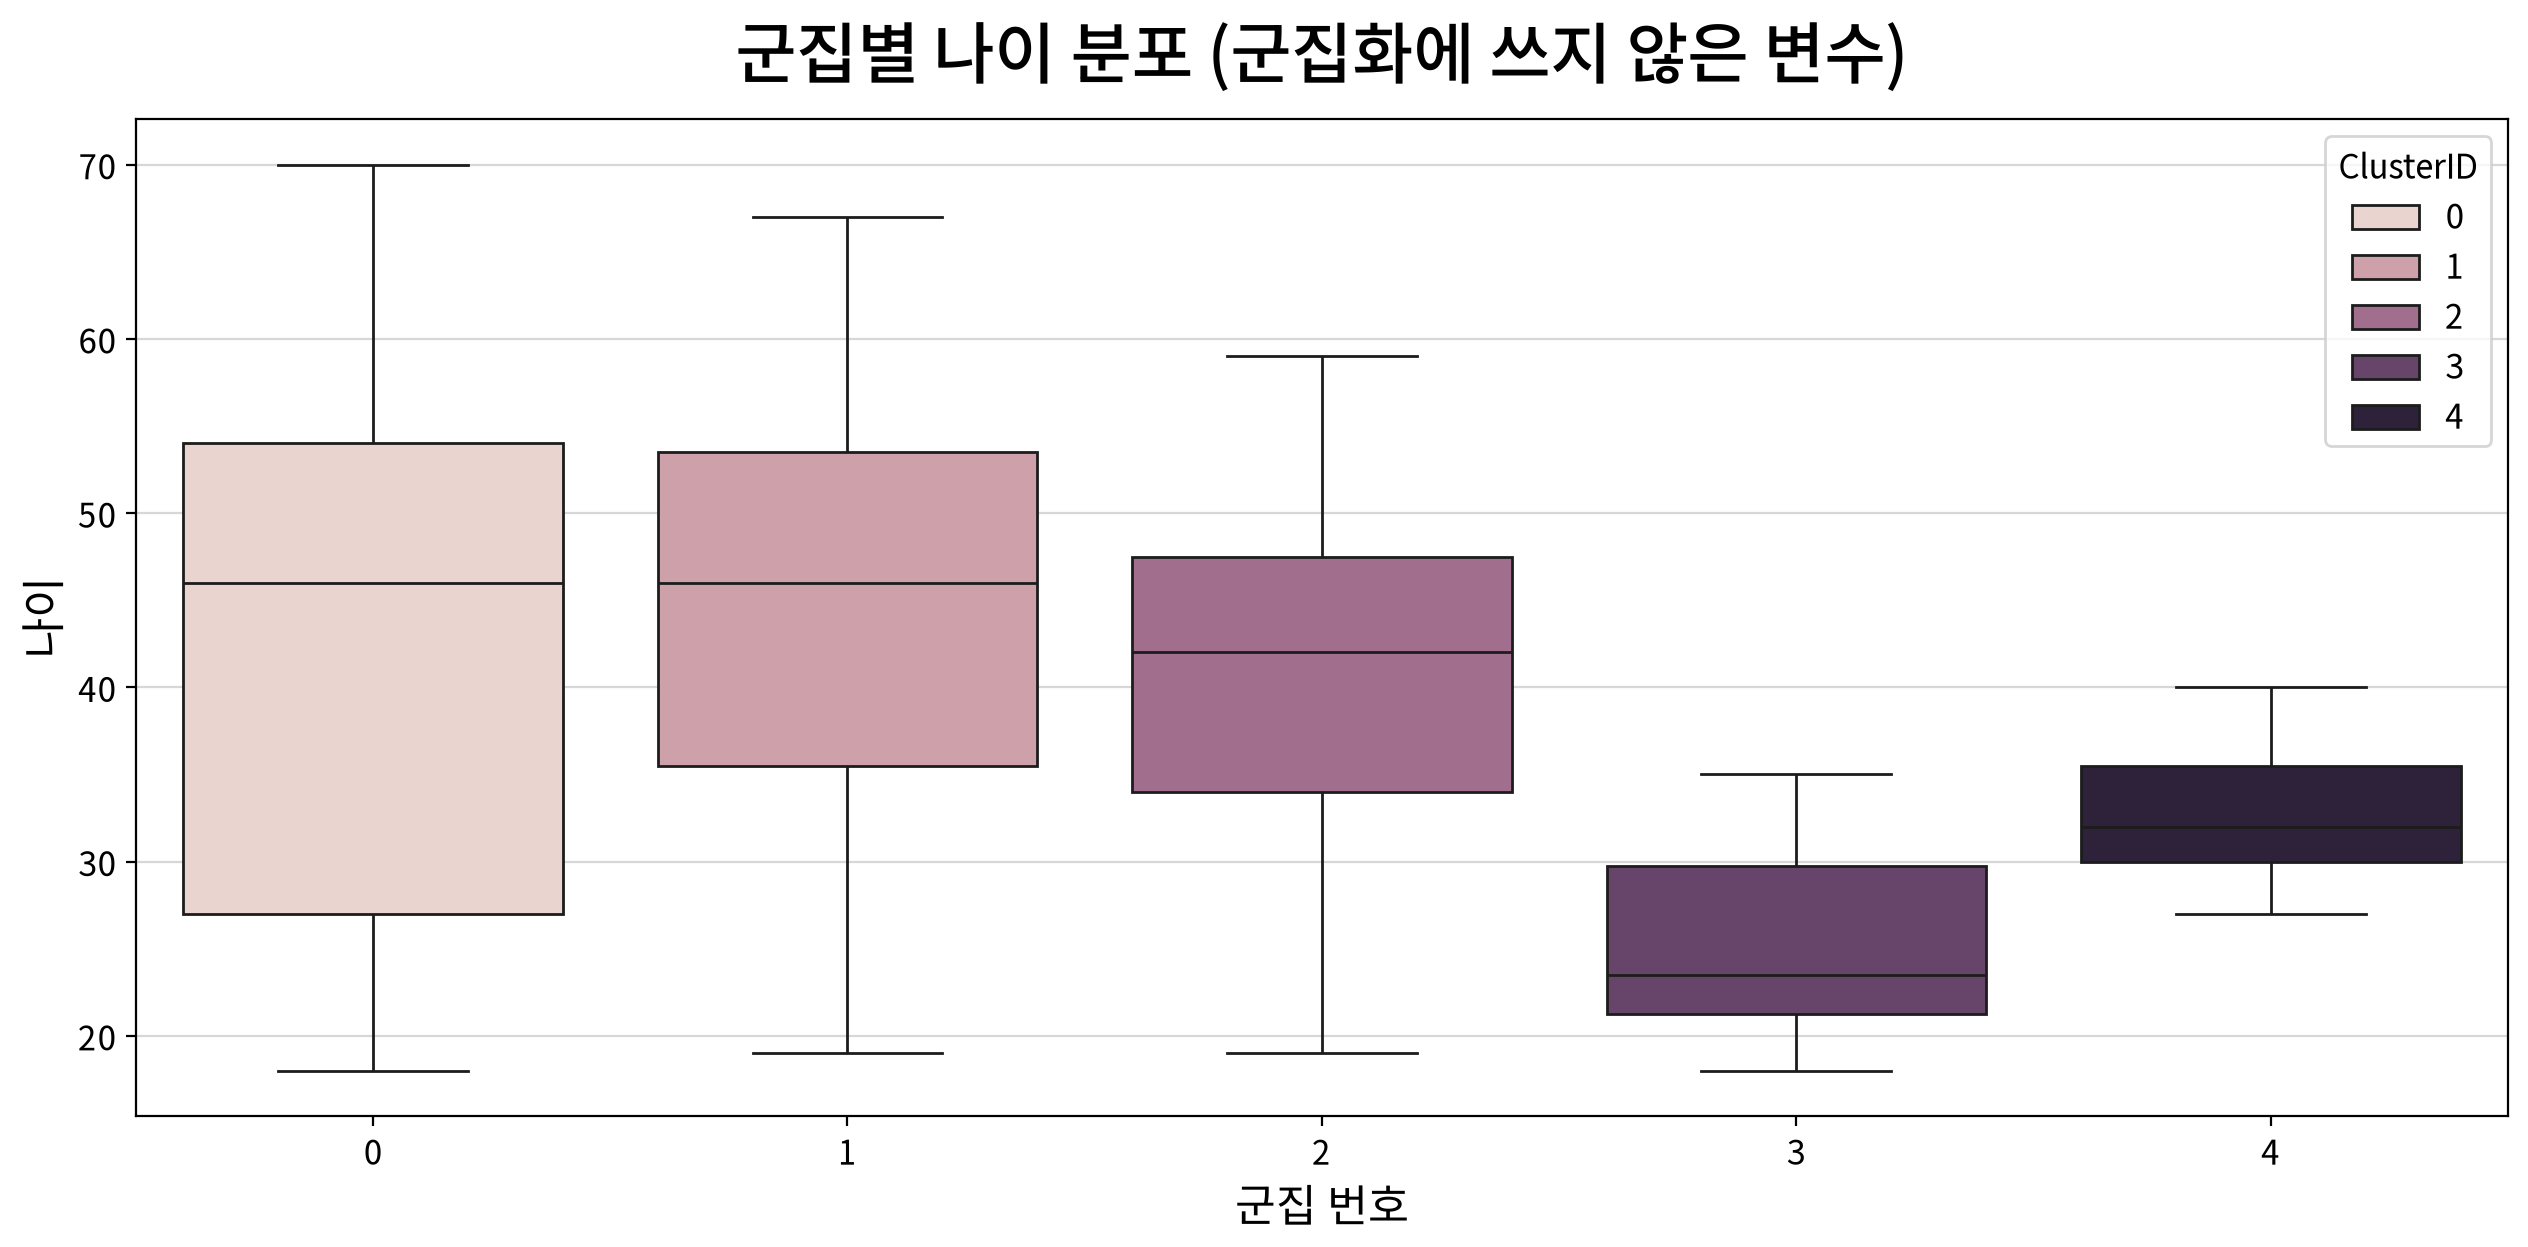

In [12]:
my_plot.boxplot(
    data=pdf, x="ClusterID", y="나이", hue="ClusterID",
    title="군집별 나이 분포 (군집화에 쓰지 않은 변수)",
    xlabel="군집 번호", ylabel="나이"
)



### 해석 — 군집화에 쓰지 않은 변수에서 나온 발견이라 근거가 더 강하다

- **적극 소비층**(군집3, 저소득·고지출)이 눈에 띄게 **젊다**
- **핵심 고객**(군집4, 고소득·고지출)도 비교적 젊은 편이다
- 나머지 세 군집은 **40대**에 몰려 있다

> **"젊은 고객은 소득과 무관하게 많이 쓴다"는 문장이 여기서 나온다**

- 나이는 거리 계산에 넣지 않았다 — 그런데도 군집 사이에 차이가 나타났다
- 앞에서 말한 "나눠 놓고 보니 나이가 달랐다"가 실제로 확인된 것이다

### 5. 범주형 변수 비율 확인 
성별의 최빈값은 대부분의 군집에서 같은 값이 나온다 \
이럴 때는 구성비를 함께 봐야 차이가 보인다 

In [13]:
# 군집 X 성별 교차표 
ct = crosstab(pdf["ClusterID"], pdf["성별"])
display(ct)

# 비율로 환산 (행 기준 %)
display((ct.div(ct.sum(axis=1), axis=0) *100).round(1))

성별,Female,Male
ClusterID,,
0,48,33
1,14,9
2,16,19
3,13,9
4,21,18


성별,Female,Male
ClusterID,,
0,59.300,40.700
1,60.900,39.100
2,45.700,54.300
3,59.100,40.900
4,53.800,46.200


## 성별은 최빈값만으로 부족하다

### 전체가 여성 56%라, 최빈값만 보면 다섯 군집이 똑같아 보인다.

**A. 최빈값 하나만 보면 "다 여성"으로 보인다 — 구성비를 봐야 한다**

전체 여성 비율이 **56%**라서 대부분의 군집에서 최빈값이 같게 나온다 → **군집 × 성별 교차표**로 확인한다

**인원수 (명)**

| 군집 | Female | Male |
|---|---|---|
| 0 | 48 | 33 |
| 1 | 14 | 9 |
| **2** | **16** | **19** |
| 3 | 13 | 9 |
| 4 | 21 | 18 |

**행 기준 (%)**

| 군집 | Female | Male |
|---|---|---|
| 0 | 59.3 | 40.7 |
| 1 | 60.9 | 39.1 |
| **2** | **45.7** | **54.3** |
| 3 | 59.1 | 40.9 |
| 4 | 53.8 | 46.2 |

> **군집 2(설득 대상)만 남성이 더 많다 — 45.7% : 54.3%**

- 최빈값 하나만 보면 다섯 군집이 거의 다 "Female"로 보이지만, **구성비를 보면 이 군집만 다르다**
- → 성별은 분리력이 약한 변수다. 페르소나 표에 넣되 주된 근거로 삼지는 않는다

---

## #05. 페르소나 분석 활용

### 1. 신규 고객은 어느 그룹일까?

◎ 신규 가입 고객이 어느 그룹에 속하는지 예측해 보자.

◎ ⚠️ **새 데이터도 반드시 학습 때와 똑같은 기준으로 스케일링해야 한다.**
  - 그래서 앞에서 스케일러를 파일로 저장해 두었다.

In [14]:
# 신규 고객 3명 (연수입, 지출점수)
new_data = [[70, 85], # 소득도 높고 많이 쓴다
            [30, 20], # 소득도 적고 적게 쓴다
            [88, 18]]  # 소득은 높은데 적게 쓴다

new_df = DataFrame(new_data, columns=df.columns)
new_df

,연수입,지출점수
0,70,85
1,30,20
2,88,18


### 2. 초기 분석과 동일한 스케일러 사용 

In [19]:
# 저장해 둔 스케일러를 불러와 똑같은 기준으로 변환 
scaler = joblib.load("models/mall_scaler.pkl")
new_scaled = DataFrame(scaler.transform(new_df), columns=df.columns)

display(new_scaled)

# 어느 군집에 속하는지 예측 
print("예측된 군집: ", estimator.predict(new_scaled))

,연수입,지출점수
0,0.360,1.351
1,-1.166,-1.172
2,1.047,-1.250


예측된 군집:  [4 1 2]


## 결론: 신규 고객 배정과 정리

### 그룹을 한 번 만들어 두면 신규 고객이 들어올 때마다 자동으로 분류된다

**A. 신규 고객 예측**

| 고객 | 연수입 | 지출점수 | 예측 군집 | 배정된 그룹 | 바로 실행할 일 |
|---|---|---|---|---|---|
| A | 70 | 85 | 4 | 핵심 고객 | 가입 즉시 VIP 프로그램 안내 |
| B | 30 | 20 | 1 | 저관여 | 비용이 큰 캠페인 대상에서 제외 |
| C | 88 | 18 | 2 | 설득 대상 | "왜 안 쓰는가" 설문 대상 |

> 새 데이터도 반드시 학습 때와 똑같은 기준으로 스케일링해야 한다 — 그래서 스케일러를 파일로 저장해 두었다

**B. 정리**

| 단계 | 사용하는 데이터 |
|---|---|
| 모델 학습 | 스케일링된 데이터 |
| 페르소나 해석 | 원본 데이터 |
| 새 데이터 예측 | 저장한 스케일러로 변환 후 예측 |

| 변수의 역할 | 이번 데이터 |
|---|---|
| 군집화 변수 — 그룹을 나눌 때 | 연수입, 지출점수 |
| 해석 변수 — 그룹을 설명할 때 | + 나이, 성별 |

> **이번 단원의 결론**
> 군집분석의 결과물은 군집 번호가 아니라 **"이 그룹은 어떤 사람들인가"**라는 문장이다.
> 그 문장이 나와야 비로소 마케팅 액션으로 이어진다.

---

## 페르소나 실무 활용 방법 (1/2)

### 군집 번호를 종속변수로 둔 분류 분석

아이디어 — 군집분석은 끝이 아니다. **"왜 이 사람은 이 그룹인가"**를 숫자로 답한다

**PCA(차원축소)** → **KMeans(비지도 학습)** → **분류값을 y로 재사용** → **원본 데이터로 분류모형** → **무엇이 그룹을 가르는가**

쇼핑몰 고객 200명 · 연수입·지출점수로 K=5 군집화 (실루엣 0.555) → 군집 번호를 지도학습의 y로 표퓰레는 역을 함

**분석 설계**

| 항목 | 내용 |
|---|---|
| 종속변수 y | 군집 번호 0~4 · 5개 범주 → 다중 분류 |
| 독립변수 X | 나이, 성별 — 해석 변수 |
| 후보 모형 | 다항 로지스틱 회귀 · 의사결정나무 · 랜덤포레스트 등 |
| 얻는 것 | 회귀계수(오즈비) · 변수 중요도 · 분류 규칙 |
| 평가 | 정확도보다 "어떤 변수가 얼마나 기여했는가" |

**먼저 짚어야 할 함정**

연수입·지출점수를 X에 그대로 넣으면 안 된다.
이 둘은 군집을 만든 변수이므로 이 두 변수가 포함되면 분류 정확도가 거의 100%가 된다.
모형은 KMeans가 그린 경계선을 되풀이하게 된다.
발견이 아니라 순환논리다.
→ **독립변수는 군집화에 쓰지 않은 변수만 사용한다.**

---

## 페르소나 실무 활용 방법 (2/2)

### 이미 보이는 근거 — 군집화에 쓰지 않은 나이가 군집마다 다르다

**군집별 나이 분포 (군집화에 쓰지 않은 변수)**

- 나이 신호 — 군집 3(적극 소비층) 평균 **25.3세** · 군집 4(핵심 고객) **32.7세** · 나머지 세 군집은 40대
- 성별은 부분적 신호 — 군집 2(설득 대상)만 남성 우세 **54.3%**, 나머지는 여성 우세
- 기대하는 결론의 형태 — **"나이가 어릴수록 적극 소비층에 속할 오즈가 커진다"**처럼 크기까지